# Deep learning : projet d'IA

**Author: alice.petit@soprasterianext.com**

**Version**: 2025/11

Pour toute remarque ou suggestion, n'hésitez pas à me contacter.

$\newcommand{\underbr}[2]{\underbrace{#1}_{\scriptscriptstyle{#2}}}$

## <font color=darkred> **Objectif de ce TP** :
Des professeurs veulent lire automatiquement les chiffres notés sur leurs copies.
Ils ne peuvent pas utiliser les copies pour des questions d'anonimisation des données.

Nous pouvons donc utiliser un jeu de données semblable pour entrainer notre modèle. On va utiliser la base de données MNIST.

On va entrainer un classifieur CNN à reconnaitre les 10 chiffres qui existent (0, 1, 2, 3, 4, 5, 6, 7, 8, 9).

Puis on va appliquer des métriques.

### Les métriques à appliquer
- Matrice de confusion
- l'accuracy
- la pertinence
- le rappel
- le score F1

## Chargement des données MNIST

In [ ]:
import pandas as pd

splits = {'train': 'mnist/train-00000-of-00001.parquet', 'test': 'mnist/test-00000-of-00001.parquet'}
df_train = pd.read_parquet("hf://datasets/ylecun/mnist/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/ylecun/mnist/" + splits["test"])

In [ ]:
X_train = df_train["image"][:1000]
y_train = df_train["label"][:1000]

In [ ]:
# TODO visualiser ce que l'on a dans X_train et y_train

In [ ]:
# TODO Afficher les 10 première images avec leurs labels
import matplotlib.pyplot as plt
from PIL import Image
import io

## Mise en forme des données MNIST

In [ ]:
# TODO séparer les données d'entrainement en un jeu de validation et d'entrainement (100, 900)

from sklearn.model_selection import train_test_split

In [ ]:
# TODO reshape les données pour qu'elles aients une shape de (nb_données, 28, 28, 1)

In [ ]:
print(X_train.shape)
print(X_val.shape)

(900, 28, 28, 1)
(100, 28, 28, 1)


In [ ]:
# TODO crée une fonction pour que tes images aient uniquement des pixels égaux à 0 ou 1

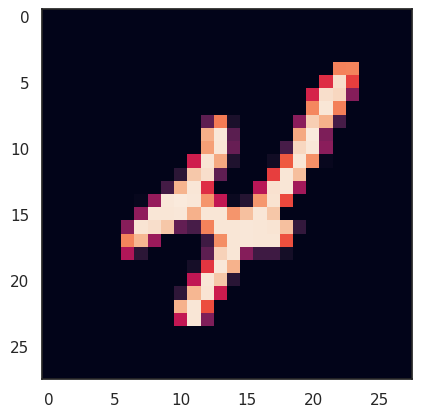

In [ ]:
plt.imshow((X_train[9].squeeze()))

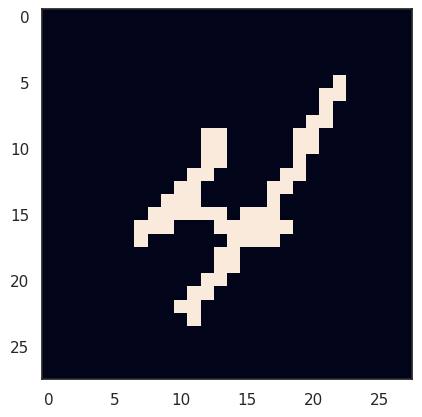

In [ ]:
image = apply_contrast(X_train[9])
plt.imshow(image.squeeze())

In [ ]:
# TODO transforme tes sorties Y en des vecteurs de taille 10 avec un 1 à l'index de la vérité

In [ ]:
print("La valeur {} est encodée vers le vecteur {}".format(y_train[0], Y_train[0]))
print("valeur {} transformée en vecteur: {}".format(y_train[20], Y_train[20]))

La valeur 5 est encodée vers le vecteur [0 0 0 0 0 1 0 0 0 0]
valeur 4 transformée en vecteur: [0 0 0 0 1 0 0 0 0 0]


## Création du modèle CNN

Les 2 premières couches de CNN auront du padding avec des filtres de taille (5,5).
La fonction d'activation "relu" sera utilisée par toutes les couches cachées du modèle.


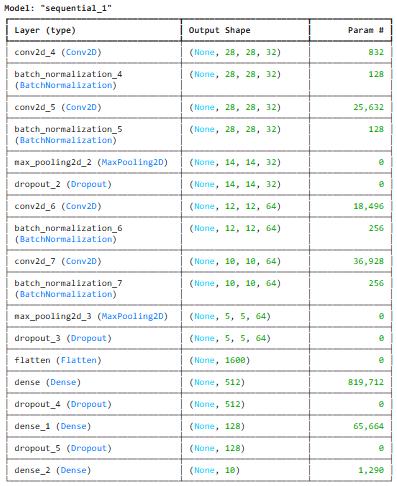

In [ ]:
# TODO crée un model keras de classification

# Librairies Keras pour la construction du réseau CNN
from keras.models import Model, Sequential
from keras.models import load_model
from keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization
from keras.layers import UpSampling2D, Dropout, Dense, Flatten

# Initialisation
model = Sequential()

# Ajoute les couches qui correspondent au schema ci-dessus

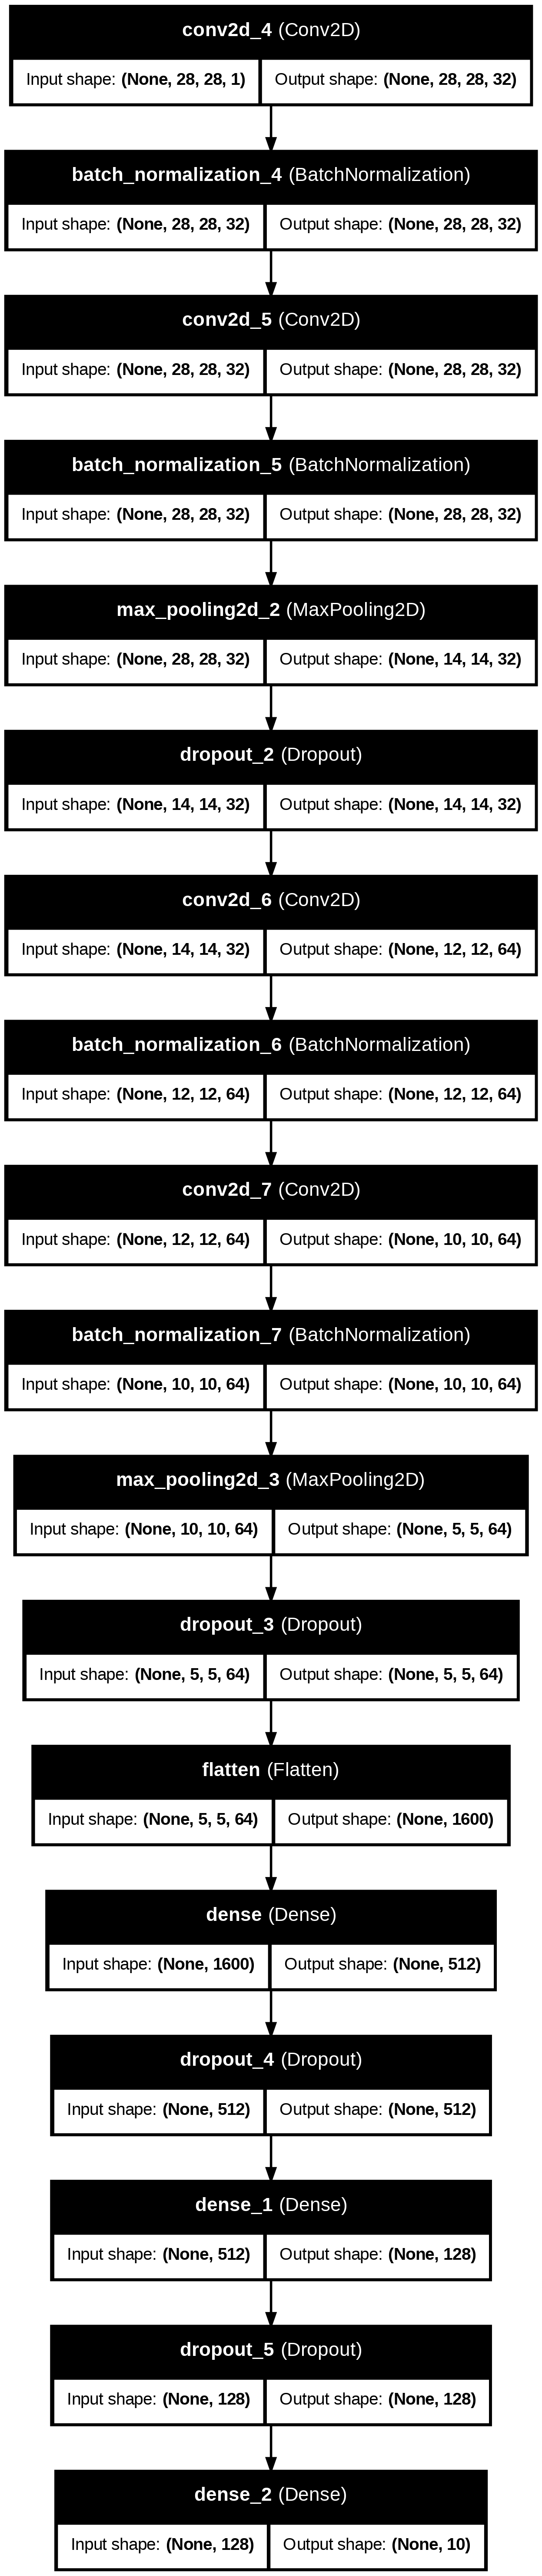

In [ ]:
from tensorflow.keras.utils import plot_model

# Visualisation du schémas de l'architecture de neurones
plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
# Récapitulatif de l'architecture modèle
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 969,322 (3.70 MB)

 Trainable params: 968,938 (3.70 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# TODO utilise ADAM en optimizer
from keras.optimizers import Adam

In [ ]:
# TODO met en place une strategie de EarlyStopping

In [ ]:
# TODO démarre l'entrainement du modèle

In [ ]:
# Evaluation de la performance du modèle
final_loss, final_acc = model.evaluate(X_val, Y_val, verbose=0)
print("Final loss: {0:.4f}, final accuracy: {1:.4f}".format(final_loss, final_acc))

Final loss: 0.3137, final accuracy: 0.9500


In [ ]:
# TODO sauvegarde le modèle

In [ ]:
# TODO charge le modèle sauvegardé

## Prédiction du modèle

In [ ]:
## TODO prédit les valeurs correspondant aux données de validation


Y_hat[0]

### Calcule de la matrice de confusion

In [ ]:
## TODO récupère les Y_true et Y_pred et crée une matrice de confusion

### Affichage d'images mal classifiées

In [ ]:
## TODO Affiche les images dont la prediction n'est pas correcte ainsi que la prédiction et celle attendue

### Calcule des métriques accuracy, precision, rappel, f1-score

In [ ]:
# TODO calcule les métriques